## HW7: Bayesian and Nonparametric Regression with Gaussian Processes

In this lab, we compare different regression methods and evaluate them.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

plt.rcParams['figure.figsize'] = (7, 5)

## Load Data

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00291/airfoil_self_noise.dat"
df = pd.read_csv(url, sep='\t', header=None)

df.columns = ['frequency', 'angle', 'chord', 'velocity', 'thickness', 'pressure']

X = df.drop('pressure', axis=1).values
y = df['pressure'].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

## Scaling

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

y_mean = y_train.mean()
y_std = y_train.std()
y_scaled = (y_train - y_mean) / y_std

## Plot Function

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

feature_index = 0
feature_names = df.drop('pressure', axis=1).columns.tolist()
figs_results_dir = Path('figs_results')
figs_results_dir.mkdir(exist_ok=True)
initials = 'senthilnathan_t'

def mse(y_true, y_pred):
    return float(mean_squared_error(y_true, y_pred))

def to_original_scale(values):
    return y_mean + y_std * values

def save_figure(fig, task_number, figure_number):
    # Save figures during notebook execution using the assignment naming scheme.
    filename = f'a7_task{task_number}_fig{figure_number}_{initials}.png'
    fig.savefig(figs_results_dir / filename, dpi=300, bbox_inches='tight')
    print(f'Saved figure: {figs_results_dir / filename}')

def make_slice_grid(n_points=200):
    x_vals = np.linspace(X_train[:, feature_index].min(), X_train[:, feature_index].max(), n_points)
    X_base = X_train.mean(axis=0)
    X_grid = np.tile(X_base, (n_points, 1))
    X_grid[:, feature_index] = x_vals
    return x_vals, X_grid

def plot_model(model, title, use_scaling=True, feature_transform=None, ax=None,
               show_scatter=True, label=None, color=None):
    x_vals, X_grid = make_slice_grid()
    X_grid_model = scaler.transform(X_grid) if use_scaling else X_grid
    if feature_transform is not None:
        X_grid_model = feature_transform(X_grid_model)

    # Convert scaled predictions back to original pressure units.
    preds = to_original_scale(model.predict(X_grid_model))

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))

    if show_scatter:
        ax.scatter(X_train[:, feature_index], y_train, alpha=0.3, s=18, label='Training data')

    ax.plot(x_vals, preds, linewidth=2.5, label=label, color=color)
    ax.set_xlabel(feature_names[feature_index])
    ax.set_ylabel('pressure')
    if title is not None:
        ax.set_title(title)
    return x_vals, preds, ax

def plot_gp_model(model, title, ax=None, show_scatter=True, label=None, color='crimson'):
    x_vals, X_grid = make_slice_grid()
    X_grid_model = scaler.transform(X_grid)
    mean_scaled, std_scaled = model.predict(X_grid_model, return_std=True)
    mean = to_original_scale(mean_scaled)
    std = y_std * std_scaled

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))

    if show_scatter:
        ax.scatter(X_train[:, feature_index], y_train, alpha=0.3, s=18, label='Training data')

    ax.plot(x_vals, mean, linewidth=2.5, color=color, label=label)
    ax.fill_between(x_vals, mean - 2 * std, mean + 2 * std, color=color, alpha=0.18)
    ax.set_xlabel(feature_names[feature_index])
    ax.set_ylabel('pressure')
    if title is not None:
        ax.set_title(title)
    return x_vals, mean, std, ax

## Task 1: Linear Regression and Global Modeling

For this task, I vary `frequency` while keeping the other four inputs fixed at their training-set means, which follows the task-sheet visualization rule. This gives a one-dimensional slice through the 5-dimensional predictor space while still using all five predictors during fitting.

I standardize both the inputs and the target for fitting. The shared plotting helper converts predictions back to the original `pressure` units before plotting, so the reported errors and the curve are directly interpretable.


Linear regression performance
     split    mse    r2
     train 22.827 0.521
validation 23.688 0.498


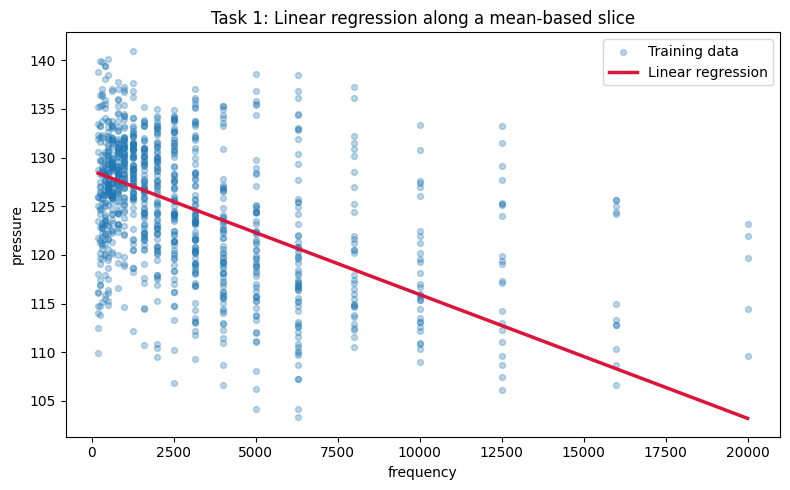

In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_scaled, y_scaled)

linear_train_pred = to_original_scale(linear_model.predict(X_scaled))
linear_val_pred = to_original_scale(linear_model.predict(X_val_scaled))
linear_metrics_df = pd.DataFrame([
    {
        'split': 'train',
        'mse': mse(y_train, linear_train_pred),
        'r2': r2_score(y_train, linear_train_pred),
    },
    {
        'split': 'validation',
        'mse': mse(y_val, linear_val_pred),
        'r2': r2_score(y_val, linear_val_pred),
    },
])

print('Linear regression performance')
print(linear_metrics_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
plot_model(
    linear_model,
    'Task 1: Linear regression along a mean-based slice',
    ax=ax,
    label='Linear regression',
    color='crimson',
)
ax.legend()
plt.tight_layout()
save_figure(fig, 1, 1)
plt.show()

### Task 1 Interpretation

The linear model gives a training MSE of about `22.83` and a validation MSE of about `23.69`, with validation `R^2` close to `0.50`. The fitted slice is almost a straight line, so it captures only a global trend in `frequency`.

The scatter around that line still shows substantial spread, which suggests that one global hyperplane is not flexible enough for this dataset. In other words, linear regression is underfitting here: it cannot represent the curvature and interaction effects that seem to be present in the airfoil measurements.


## Task 2: Polynomial Regression and Model Complexity

I build polynomial regression models using standardized predictors and a standardized target, then transform the predictions back to the original `pressure` scale for interpretation. Degrees `1` through `6` are shown in a `3 x 2` grid so the effect of increasing model complexity is easy to compare.


Polynomial regression performance
 degree  n_features  train_mse  val_mse  train_r2  val_r2
      1           5     22.827   23.688     0.521   0.498
      2          20     16.785   17.821     0.648   0.623
      3          55     11.198   12.921     0.765   0.726
      4         125      6.607    8.565     0.861   0.819
      5         251      4.190    9.792     0.912   0.793
      6         461      2.869   50.882     0.940  -0.078


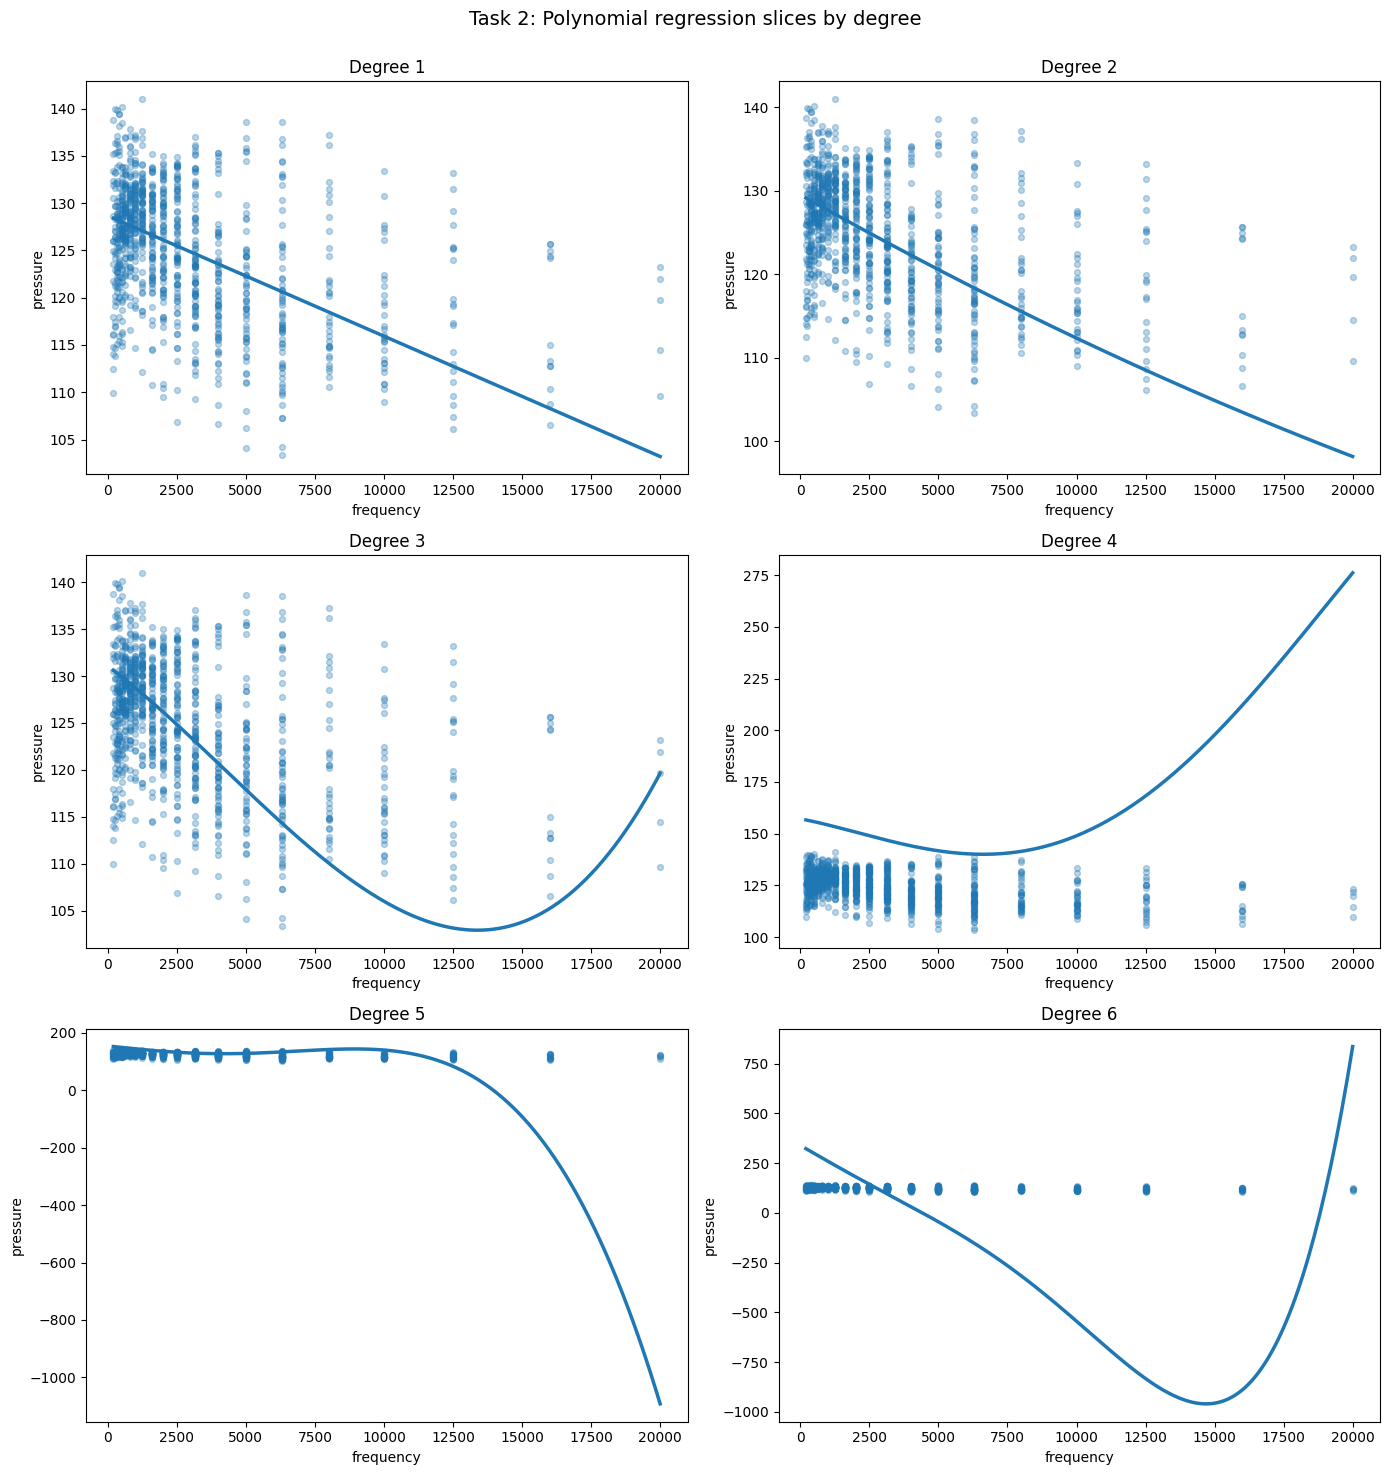

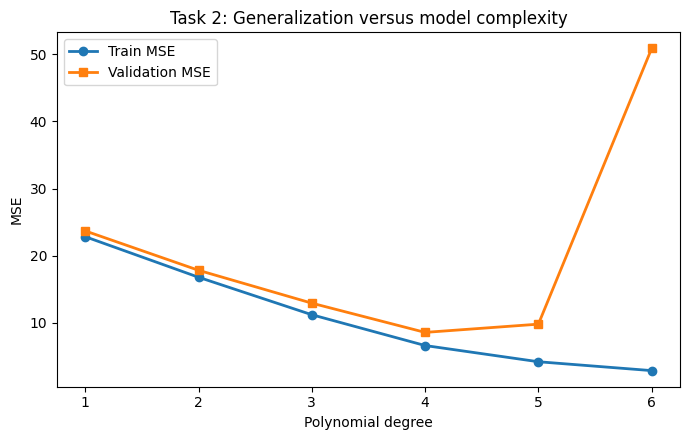

In [ ]:
degrees = [1, 2, 3, 4, 5, 6]
poly_results = []

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.ravel()

for ax, degree in zip(axes, degrees):
    if degree == 1:
        model = LinearRegression()
        model.fit(X_scaled, y_scaled)
        train_pred = to_original_scale(model.predict(X_scaled))
        val_pred = to_original_scale(model.predict(X_val_scaled))
        n_features = X_scaled.shape[1]
        plot_model(model, f'Degree {degree}', ax=ax)
    else:
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_poly_train = poly.fit_transform(X_scaled)
        X_poly_val = poly.transform(X_val_scaled)

        model = LinearRegression()
        model.fit(X_poly_train, y_scaled)

        train_pred = to_original_scale(model.predict(X_poly_train))
        val_pred = to_original_scale(model.predict(X_poly_val))
        n_features = X_poly_train.shape[1]
        plot_model(model, f'Degree {degree}', feature_transform=poly.transform, ax=ax)

    poly_results.append({
        'degree': degree,
        'n_features': n_features,
        'train_mse': mse(y_train, train_pred),
        'val_mse': mse(y_val, val_pred),
        'train_r2': r2_score(y_train, train_pred),
        'val_r2': r2_score(y_val, val_pred),
    })

fig.suptitle('Task 2: Polynomial regression slices by degree', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.98])
save_figure(fig, 2, 1)
plt.show()

poly_results_df = pd.DataFrame(poly_results)
print('Polynomial regression performance')
print(poly_results_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(poly_results_df['degree'], poly_results_df['train_mse'], marker='o', linewidth=2, label='Train MSE')
ax.plot(poly_results_df['degree'], poly_results_df['val_mse'], marker='s', linewidth=2, label='Validation MSE')
ax.set_xlabel('Polynomial degree')
ax.set_ylabel('MSE')
ax.set_title('Task 2: Generalization versus model complexity')
ax.set_xticks(degrees)
ax.legend()
fig.tight_layout()
save_figure(fig, 2, 2)
plt.show()

### Task 2 Interpretation

Across degrees `1` to `4`, validation performance improves steadily: the validation MSE falls from about `23.69` to `17.82`, `12.92`, and then `8.56`, while the validation `R^2` rises to about `0.82` at degree `4`. This suggests that moderate nonlinearity helps the model capture structure that the linear fit misses.

Beyond degree `4`, the pattern changes. Degree `5` still fits the training data better but validation performance starts to worsen, and degree `6` deteriorates sharply with validation MSE around `50.88` and a negative validation `R^2`. The separate subplots make this easier to see: higher-degree fits become much more unstable, especially near the boundary of the frequency range, which is a strong sign of overfitting.


## Task 3: Regularization and Ridge Regression

To isolate the effect of regularization, I keep the polynomial degree fixed at `6`, which was highly unstable in Task 2, and vary the ridge penalty `alpha` over several orders of magnitude. This makes it easier to see how regularization changes the fitted curve.


Ridge regression performance (degree 6)
  alpha  train_mse  val_mse  train_r2  val_r2
   0.01      3.096   15.012     0.935   0.682
   0.10      3.302   16.347     0.931   0.654
   1.00      3.744   17.261     0.922   0.634
  10.00      5.133   13.324     0.892   0.718
 100.00      9.337   12.169     0.804   0.742
1000.00     16.920   15.774     0.645   0.666


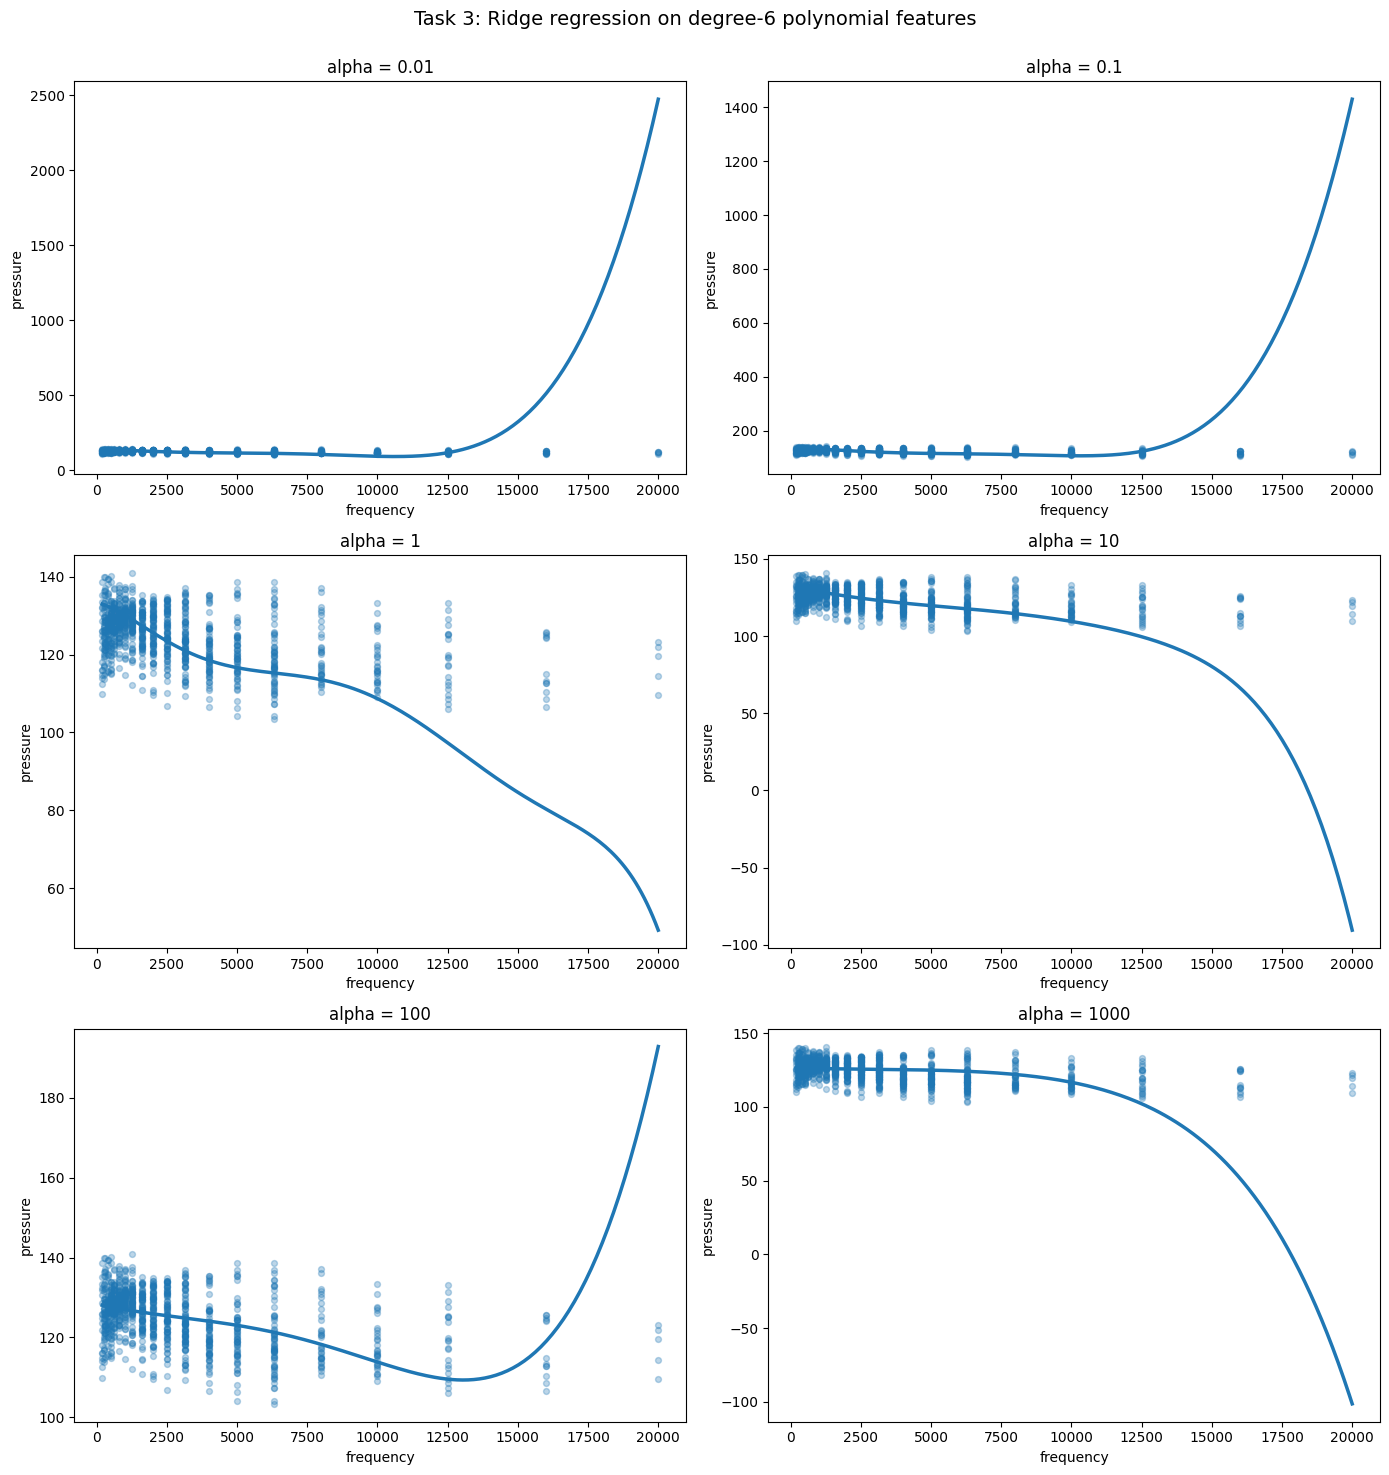

In [ ]:
ridge_degree = 6
ridge_alphas = [0.01, 0.1, 1, 10, 100, 1000]
ridge_results = []

ridge_poly = PolynomialFeatures(degree=ridge_degree, include_bias=False)
X_ridge_train = ridge_poly.fit_transform(X_scaled)
X_ridge_val = ridge_poly.transform(X_val_scaled)

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.ravel()

for ax, alpha in zip(axes, ridge_alphas):
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_ridge_train, y_scaled)

    train_pred = to_original_scale(ridge_model.predict(X_ridge_train))
    val_pred = to_original_scale(ridge_model.predict(X_ridge_val))

    ridge_results.append({
        'alpha': alpha,
        'train_mse': mse(y_train, train_pred),
        'val_mse': mse(y_val, val_pred),
        'train_r2': r2_score(y_train, train_pred),
        'val_r2': r2_score(y_val, val_pred),
    })

    plot_model(ridge_model, f'alpha = {alpha}', feature_transform=ridge_poly.transform, ax=ax)

fig.suptitle('Task 3: Ridge regression on degree-6 polynomial features', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.98])
save_figure(fig, 3, 1)
plt.show()

ridge_results_df = pd.DataFrame(ridge_results)
print('Ridge regression performance (degree 6)')
print(ridge_results_df.round(3).to_string(index=False))

### Task 3 Interpretation

Regularization clearly stabilizes the degree-6 polynomial model. With very small `alpha`, the curve still inherits much of the instability from the unregularized fit, but as `alpha` increases the fitted function becomes smoother and less extreme.

In this sweep, validation MSE improves from about `15.01` at `alpha = 0.01` to about `12.17` at `alpha = 100`, before worsening again to about `15.77` at `alpha = 1000`. That pattern matches the bias-variance tradeoff: moderate regularization reduces variance, but too much regularization pushes the model toward underfitting.


## Task 4: Model Selection and Generalization

For model selection, I use `5`-fold cross-validation over polynomial degrees `1` through `6` and multiple ridge penalties rather than relying on a single split. Inside each fold, scaling is refit on the fold-specific training data to avoid leakage from the validation fold.


Top cross-validation results
 degree  alpha  train_mse  cv_mse
      4   0.01      6.393  10.763
      4   0.10      6.572  10.771
      4   1.00      7.054  10.859
      4  10.00      8.427  11.257
      5  10.00      6.392  12.595
      5   1.00      4.681  13.070
      3   1.00     11.083  13.230
      3   0.10     10.998  13.277
      3   0.01     10.989  13.319
      3  10.00     11.650  13.447
Best CV configuration: degree=4, alpha=0.01
Holdout check for the best CV model: validation MSE=8.449, R^2=0.821


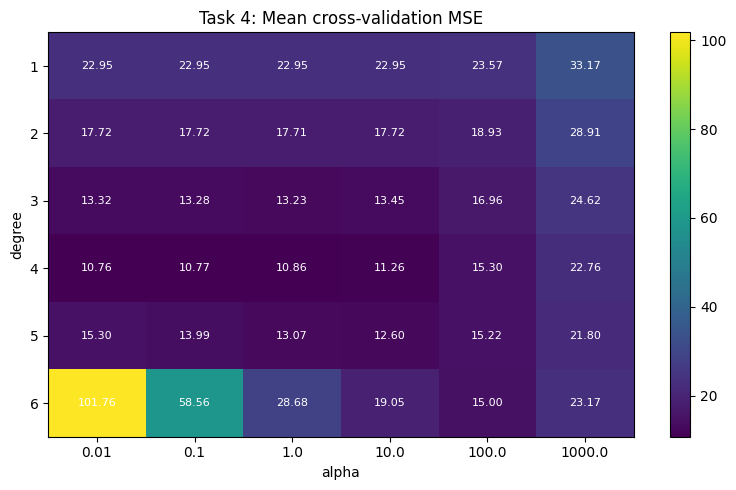

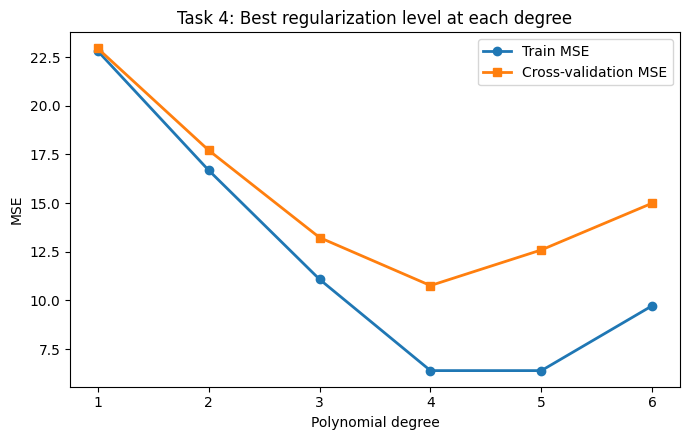

In [ ]:
from sklearn.model_selection import KFold

cv_degrees = [1, 2, 3, 4, 5, 6]
cv_alphas = [0.01, 0.1, 1, 10, 100, 1000]
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_records = []

for degree in cv_degrees:
    for alpha in cv_alphas:
        fold_train_mse = []
        fold_val_mse = []

        for train_idx, val_idx in kf.split(X_train):
            X_fold_train = X_train[train_idx]
            X_fold_val = X_train[val_idx]
            y_fold_train = y_train[train_idx]
            y_fold_val = y_train[val_idx]

            fold_scaler = StandardScaler()
            X_fold_train_scaled = fold_scaler.fit_transform(X_fold_train)
            X_fold_val_scaled = fold_scaler.transform(X_fold_val)

            y_fold_mean = y_fold_train.mean()
            y_fold_std = y_fold_train.std()
            y_fold_train_scaled = (y_fold_train - y_fold_mean) / y_fold_std

            fold_poly = PolynomialFeatures(degree=degree, include_bias=False)
            X_fold_poly_train = fold_poly.fit_transform(X_fold_train_scaled)
            X_fold_poly_val = fold_poly.transform(X_fold_val_scaled)

            fold_model = Ridge(alpha=alpha)
            fold_model.fit(X_fold_poly_train, y_fold_train_scaled)

            train_pred = y_fold_mean + y_fold_std * fold_model.predict(X_fold_poly_train)
            val_pred = y_fold_mean + y_fold_std * fold_model.predict(X_fold_poly_val)

            fold_train_mse.append(mse(y_fold_train, train_pred))
            fold_val_mse.append(mse(y_fold_val, val_pred))

        cv_records.append({
            'degree': degree,
            'alpha': alpha,
            'train_mse': np.mean(fold_train_mse),
            'cv_mse': np.mean(fold_val_mse),
        })

cv_results_df = pd.DataFrame(cv_records)
best_cv_row = cv_results_df.loc[cv_results_df['cv_mse'].idxmin()]
best_degree = int(best_cv_row['degree'])
best_alpha = float(best_cv_row['alpha'])

print('Top cross-validation results')
print(cv_results_df.nsmallest(10, 'cv_mse').round(3).to_string(index=False))
print(f'Best CV configuration: degree={best_degree}, alpha={best_alpha}')

cv_heatmap = cv_results_df.pivot(index='degree', columns='alpha', values='cv_mse')
fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(cv_heatmap.values, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(cv_heatmap.columns)))
ax.set_xticklabels([str(col) for col in cv_heatmap.columns])
ax.set_yticks(range(len(cv_heatmap.index)))
ax.set_yticklabels(cv_heatmap.index)
ax.set_xlabel('alpha')
ax.set_ylabel('degree')
ax.set_title('Task 4: Mean cross-validation MSE')
for i in range(cv_heatmap.shape[0]):
    for j in range(cv_heatmap.shape[1]):
        ax.text(j, i, f'{cv_heatmap.values[i, j]:.2f}', ha='center', va='center', color='white', fontsize=8)
fig.colorbar(image, ax=ax)
fig.tight_layout()
save_figure(fig, 4, 1)
plt.show()

best_by_degree_df = cv_results_df.loc[cv_results_df.groupby('degree')['cv_mse'].idxmin()].sort_values('degree')
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(best_by_degree_df['degree'], best_by_degree_df['train_mse'], marker='o', linewidth=2, label='Train MSE')
ax.plot(best_by_degree_df['degree'], best_by_degree_df['cv_mse'], marker='s', linewidth=2, label='Cross-validation MSE')
ax.set_xlabel('Polynomial degree')
ax.set_ylabel('MSE')
ax.set_title('Task 4: Best regularization level at each degree')
ax.set_xticks(best_by_degree_df['degree'])
ax.legend()
fig.tight_layout()
save_figure(fig, 4, 2)
plt.show()

best_ridge_poly = PolynomialFeatures(degree=best_degree, include_bias=False)
X_best_ridge_train = best_ridge_poly.fit_transform(X_scaled)
X_best_ridge_val = best_ridge_poly.transform(X_val_scaled)

best_ridge_model = Ridge(alpha=best_alpha)
best_ridge_model.fit(X_best_ridge_train, y_scaled)

best_ridge_train_pred = to_original_scale(best_ridge_model.predict(X_best_ridge_train))
best_ridge_val_pred = to_original_scale(best_ridge_model.predict(X_best_ridge_val))

best_ridge_holdout_mse = mse(y_val, best_ridge_val_pred)
best_ridge_holdout_r2 = r2_score(y_val, best_ridge_val_pred)
print(
    f'Holdout check for the best CV model: validation MSE={best_ridge_holdout_mse:.3f}, '
    f'R^2={best_ridge_holdout_r2:.3f}'
)

### Task 4 Interpretation

Cross-validation over degrees `1` to `6` selects a degree-`4` ridge model with `alpha = 0.01` as the best balance between fit and generalization. Its mean cross-validation MSE is about `10.76`, and when refit on the full training split it gives a holdout validation MSE of about `8.45`.

The training error keeps dropping as degree increases, but the cross-validation error starts rising again for degrees `5` and `6`. That is exactly why model selection matters: highly complex models can look excellent on the data they were fit to, yet generalize poorly once they are asked to predict unseen observations.


## Task 5: Kernel-Based Regression and Local Learning

For kernel-based regression, I use kernel ridge with an RBF kernel. I keep the regularization fixed at `alpha = 0.01` and vary `gamma`, which controls how local the similarity weighting becomes.


Kernel ridge performance
 alpha  gamma  train_mse  val_mse  train_r2  val_r2
  0.01  0.001     19.868   21.382     0.583   0.547
  0.01  0.010     14.401   15.736     0.698   0.667
  0.01  0.100      6.861    8.351     0.856   0.823
  0.01  1.000      2.109    4.860     0.956   0.897
  0.01 10.000      0.417   14.814     0.991   0.686
Best kernel ridge configuration: alpha=0.01, gamma=1.0


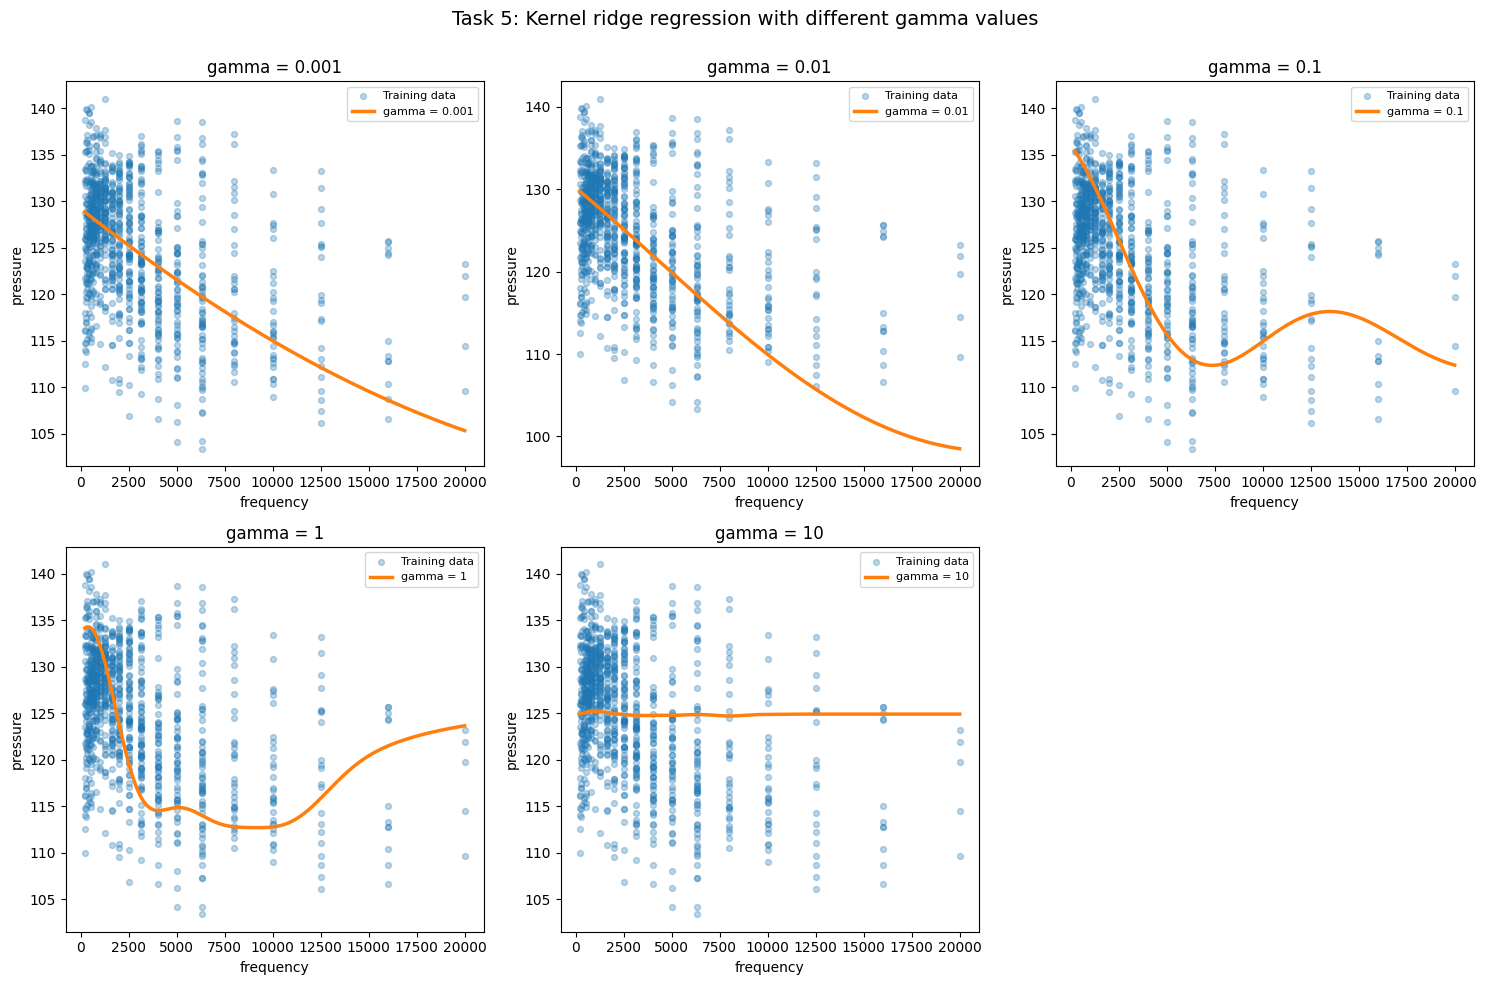

In [ ]:
kernel_alpha = 0.01
kernel_gammas = [0.001, 0.01, 0.1, 1, 10]
kernel_results = []

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for ax, gamma in zip(axes, kernel_gammas):
    kernel_model = KernelRidge(alpha=kernel_alpha, kernel='rbf', gamma=gamma)
    kernel_model.fit(X_scaled, y_scaled)

    train_pred = to_original_scale(kernel_model.predict(X_scaled))
    val_pred = to_original_scale(kernel_model.predict(X_val_scaled))

    kernel_results.append({
        'alpha': kernel_alpha,
        'gamma': gamma,
        'train_mse': mse(y_train, train_pred),
        'val_mse': mse(y_val, val_pred),
        'train_r2': r2_score(y_train, train_pred),
        'val_r2': r2_score(y_val, val_pred),
    })

    plot_model(kernel_model, f'gamma = {gamma}', ax=ax, label=f'gamma = {gamma}', color='tab:orange')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].axis('off')
fig.suptitle('Task 5: Kernel ridge regression with different gamma values', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.98])
save_figure(fig, 5, 1)
plt.show()

kernel_results_df = pd.DataFrame(kernel_results)
best_kernel_row = kernel_results_df.loc[kernel_results_df['val_mse'].idxmin()]
best_kernel_alpha = float(best_kernel_row['alpha'])
best_kernel_gamma = float(best_kernel_row['gamma'])

print('Kernel ridge performance')
print(kernel_results_df.round(3).to_string(index=False))
print(f'Best kernel ridge configuration: alpha={best_kernel_alpha}, gamma={best_kernel_gamma}')

### Task 5 Interpretation

The kernel parameter has a clear locality effect. Very small `gamma` values produce broad, almost global smoothing, while larger `gamma` values make predictions depend more strongly on nearby observations.

In this sweep, `gamma = 1` gives the best validation MSE at about `4.86`, which is much better than the best polynomial and ridge models. But pushing locality too far hurts generalization again: `gamma = 10` drives the validation MSE back up to about `14.81`, showing that an overly local fit can become unstable.


## Task 6: Gaussian Process Regression and Uncertainty

A Gaussian Process keeps the same similarity-based flavor as kernel methods, but it also gives a predictive uncertainty estimate. I first examine how fixed RBF length scales affect performance, then fit an optimized GP and visualize its predictive mean together with a `± 2σ` uncertainty band.


Fixed-length-scale GP sensitivity
 length_scale  val_mse  val_r2  mean_pred_std
          0.1   30.056   0.363          5.406
          0.3   10.798   0.771          3.806
          1.0    7.062   0.850          2.438
          3.0   12.834   0.728          2.225
Optimized GP kernel
1.12**2 * RBF(length_scale=[0.113, 1.12, 0.732, 3.29, 0.482]) + WhiteKernel(noise_level=0.0158)
Optimized GP holdout MSE=4.456, R^2=0.906
Average predictive standard deviation on the holdout split: 1.569


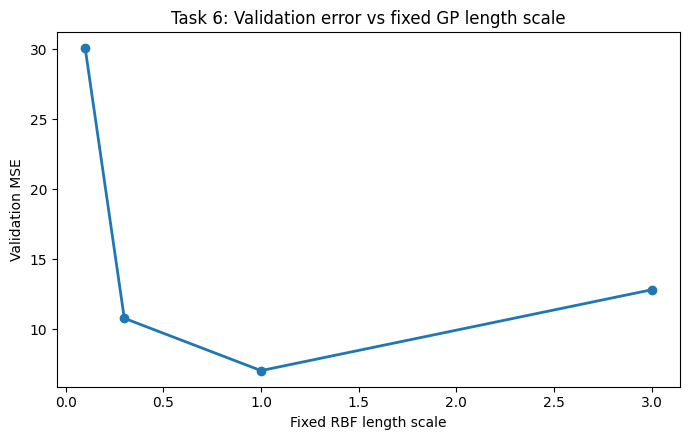

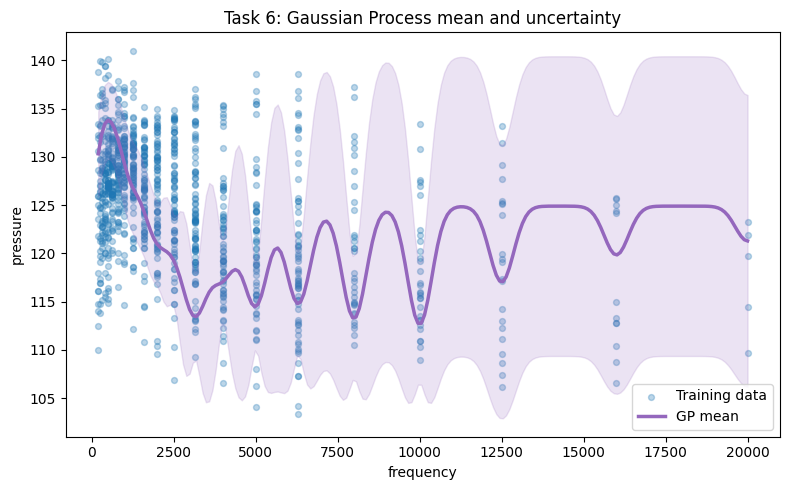

In [ ]:
from sklearn.gaussian_process.kernels import WhiteKernel

fixed_length_scales = [0.1, 0.3, 1.0, 3.0]
gp_sensitivity = []

for length_scale in fixed_length_scales:
    fixed_kernel = C(1.0) * RBF(length_scale=np.ones(X_scaled.shape[1]) * length_scale) + WhiteKernel(noise_level=0.1)
    gp_fixed = GaussianProcessRegressor(kernel=fixed_kernel, optimizer=None, normalize_y=False, random_state=42)
    gp_fixed.fit(X_scaled, y_scaled)

    val_mean_scaled, val_std_scaled = gp_fixed.predict(X_val_scaled, return_std=True)
    val_mean = to_original_scale(val_mean_scaled)

    gp_sensitivity.append({
        'length_scale': length_scale,
        'val_mse': mse(y_val, val_mean),
        'val_r2': r2_score(y_val, val_mean),
        'mean_pred_std': float(np.mean(y_std * val_std_scaled)),
    })

gp_sensitivity_df = pd.DataFrame(gp_sensitivity)
print('Fixed-length-scale GP sensitivity')
print(gp_sensitivity_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(gp_sensitivity_df['length_scale'], gp_sensitivity_df['val_mse'], marker='o', linewidth=2)
ax.set_xlabel('Fixed RBF length scale')
ax.set_ylabel('Validation MSE')
ax.set_title('Task 6: Validation error vs fixed GP length scale')
fig.tight_layout()
save_figure(fig, 6, 1)
plt.show()

optimized_kernel = C(1.0, (1e-2, 1e2)) * RBF(
    length_scale=np.ones(X_scaled.shape[1]),
    length_scale_bounds=(1e-2, 1e2),
) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))

gp_model = GaussianProcessRegressor(
    kernel=optimized_kernel,
    alpha=0.0,
    normalize_y=False,
    n_restarts_optimizer=0,
    random_state=42,
)
gp_model.fit(X_scaled, y_scaled)

gp_train_mean, _ = gp_model.predict(X_scaled, return_std=True)
gp_val_mean, gp_val_std = gp_model.predict(X_val_scaled, return_std=True)

gp_train_pred = to_original_scale(gp_train_mean)
gp_val_pred = to_original_scale(gp_val_mean)

gp_val_mse = mse(y_val, gp_val_pred)
gp_val_r2 = r2_score(y_val, gp_val_pred)
print('Optimized GP kernel')
print(gp_model.kernel_)
print(f'Optimized GP holdout MSE={gp_val_mse:.3f}, R^2={gp_val_r2:.3f}')
print(f'Average predictive standard deviation on the holdout split: {float(np.mean(gp_val_std) * y_std):.3f}')

fig, ax = plt.subplots(figsize=(8, 5))
plot_gp_model(gp_model, 'Task 6: Gaussian Process mean and uncertainty', ax=ax, label='GP mean', color='tab:purple')
ax.legend()
plt.tight_layout()
save_figure(fig, 6, 2)
plt.show()

### Task 6 Interpretation

Among the fixed-length-scale GP models, a moderate length scale around `1.0` works best, with validation MSE about `7.06`. Very short length scales are too local and perform poorly, while very large length scales smooth the function too aggressively.

After optimizing the kernel hyperparameters, the GP improves further to a validation MSE of about `4.46`, which is the best holdout performance in this notebook. The uncertainty band is narrower in regions where the slice passes through many nearby training points and wider where the model has less local support. That is the main difference from kernel ridge: the GP gives both a mean prediction and a calibrated uncertainty estimate.


## Task 7: Comparative Analysis and Interpretation

The final step is to compare one representative model from each family: linear regression, polynomial regression, ridge regression, kernel ridge, and Gaussian Process regression. For the regularized methods, I use the best settings identified in the earlier tasks.


Holdout comparison across model families
                    model  val_mse  val_r2
         Gaussian Process    4.456   0.906
   Kernel ridge gamma 1.0    4.860   0.897
Ridge degree 4 alpha 0.01    8.449   0.821
      Polynomial degree 4    8.565   0.819
                   Linear   23.688   0.498
Selected model: Gaussian Process


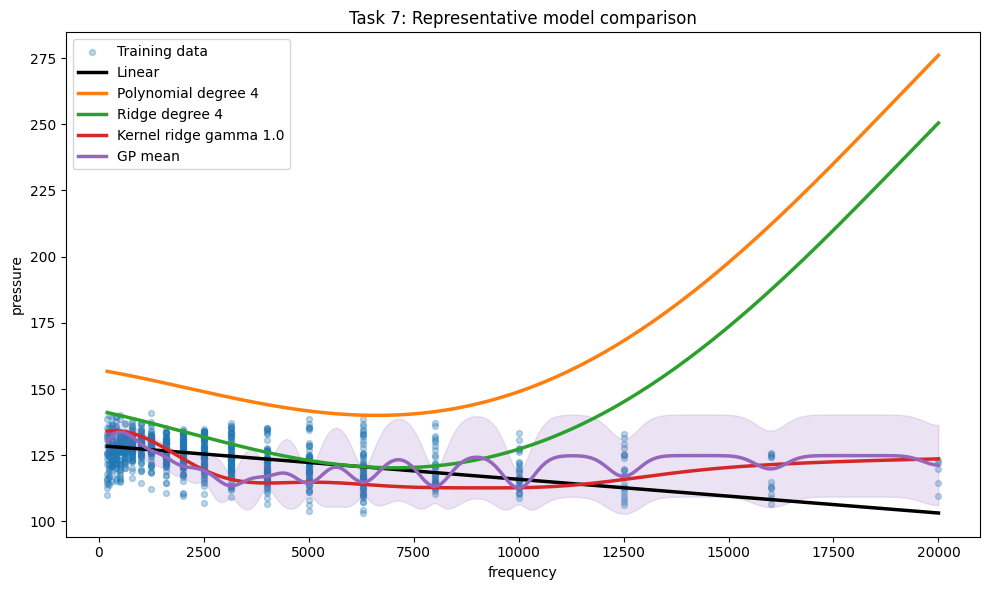

In [ ]:
comparison_rows = []

comparison_linear_model = LinearRegression()
comparison_linear_model.fit(X_scaled, y_scaled)
comparison_linear_val_pred = to_original_scale(comparison_linear_model.predict(X_val_scaled))
comparison_rows.append({
    'model': 'Linear',
    'val_mse': mse(y_val, comparison_linear_val_pred),
    'val_r2': r2_score(y_val, comparison_linear_val_pred),
})

comparison_poly_degree = 4
comparison_poly = PolynomialFeatures(degree=comparison_poly_degree, include_bias=False)
X_comparison_poly_train = comparison_poly.fit_transform(X_scaled)
X_comparison_poly_val = comparison_poly.transform(X_val_scaled)
comparison_poly_model = LinearRegression()
comparison_poly_model.fit(X_comparison_poly_train, y_scaled)
comparison_poly_val_pred = to_original_scale(comparison_poly_model.predict(X_comparison_poly_val))
comparison_rows.append({
    'model': 'Polynomial degree 4',
    'val_mse': mse(y_val, comparison_poly_val_pred),
    'val_r2': r2_score(y_val, comparison_poly_val_pred),
})

comparison_ridge_poly = PolynomialFeatures(degree=best_degree, include_bias=False)
X_comparison_ridge_train = comparison_ridge_poly.fit_transform(X_scaled)
X_comparison_ridge_val = comparison_ridge_poly.transform(X_val_scaled)
comparison_ridge_model = Ridge(alpha=best_alpha)
comparison_ridge_model.fit(X_comparison_ridge_train, y_scaled)
comparison_ridge_val_pred = to_original_scale(comparison_ridge_model.predict(X_comparison_ridge_val))
comparison_rows.append({
    'model': f'Ridge degree {best_degree} alpha {best_alpha}',
    'val_mse': mse(y_val, comparison_ridge_val_pred),
    'val_r2': r2_score(y_val, comparison_ridge_val_pred),
})

comparison_kernel_model = KernelRidge(alpha=best_kernel_alpha, kernel='rbf', gamma=best_kernel_gamma)
comparison_kernel_model.fit(X_scaled, y_scaled)
comparison_kernel_val_pred = to_original_scale(comparison_kernel_model.predict(X_val_scaled))
comparison_rows.append({
    'model': f'Kernel ridge gamma {best_kernel_gamma}',
    'val_mse': mse(y_val, comparison_kernel_val_pred),
    'val_r2': r2_score(y_val, comparison_kernel_val_pred),
})

comparison_gp_val_pred = to_original_scale(gp_model.predict(X_val_scaled))
comparison_rows.append({
    'model': 'Gaussian Process',
    'val_mse': mse(y_val, comparison_gp_val_pred),
    'val_r2': r2_score(y_val, comparison_gp_val_pred),
})

comparison_df = pd.DataFrame(comparison_rows).sort_values('val_mse')
print('Holdout comparison across model families')
print(comparison_df.round(3).to_string(index=False))
print(f"Selected model: {comparison_df.iloc[0]['model']}")

fig, ax = plt.subplots(figsize=(10, 6))
plot_model(comparison_linear_model, 'Task 7: Representative model comparison', ax=ax, label='Linear', color='black')
plot_model(comparison_poly_model, None, feature_transform=comparison_poly.transform, ax=ax, show_scatter=False, label='Polynomial degree 4', color='tab:orange')
plot_model(comparison_ridge_model, None, feature_transform=comparison_ridge_poly.transform, ax=ax, show_scatter=False, label=f'Ridge degree {best_degree}', color='tab:green')
plot_model(comparison_kernel_model, None, ax=ax, show_scatter=False, label=f'Kernel ridge gamma {best_kernel_gamma}', color='tab:red')
plot_gp_model(gp_model, None, ax=ax, show_scatter=False, label='GP mean', color='tab:purple')
ax.legend(loc='best')
plt.tight_layout()
save_figure(fig, 7, 1)
plt.show()

### Task 7 Interpretation

The comparison table shows a clear ordering on the holdout split: the optimized Gaussian Process performs best with validation MSE about `4.46`, followed closely by kernel ridge at about `4.86`. The best polynomial and ridge models are both around `8.5`, while linear regression is much worse at about `23.69`.

This pattern lines up with the modeling assumptions. Linear regression is a global model with very limited flexibility. Polynomial regression can capture nonlinearity, but high-degree fits become unstable. Ridge regularization stabilizes those fits, yet the selected ridge model still behaves like a global basis expansion. Kernel ridge shifts the focus to local similarity, which helps substantially, and the Gaussian Process adds the extra benefit of uncertainty quantification.

If I had to choose one model for this dataset, I would choose the optimized Gaussian Process because it achieves the lowest validation MSE while also providing uncertainty bands. The tradeoff is interpretability and computation: GP models are more expensive and less transparent than linear or polynomial models, but for this dataset that extra modeling structure appears worthwhile.
